# Machine Failure Prediction

## Objective:
The goal of this project is to predict machine failures based on sensor readings and operational settings.
Predicting potential failures in advance helps reduce maintenance costs, downtime, and improves overall production efficiency.
## Project Details:
Machines in manufacturing plants often fail unexpectedly, causing production delays and additional costs.
By analyzing real-time data from sensors such as temperature, torque, and rotational speed, we can build a predictive model that classifies whether a machine will fail or not in the near future.
This enables:
•	Preventive maintenance instead of reactive repair
•	Cost and downtime reduction
•	Improved equipment reliability
Data Description


## 1. Data Understanding
•	Import libraries and load dataset using pandas
•	Check data shape, column names, and data types
•	Identify target and feature columns
•	Understand value counts of Machine failure (check imbalance data)


In [114]:
import pandas as pd 
# ignore non-harmful warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [115]:
df = pd.read_csv("datasets-train.csv")
df

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136424,136424,M22284,M,300.1,311.4,1530,37.5,210,0,0,0,0,0,0
136425,136425,H38017,H,297.5,308.5,1447,49.1,2,0,0,0,0,0,0
136426,136426,L54690,L,300.5,311.8,1524,38.5,214,0,0,0,0,0,0
136427,136427,L53876,L,301.7,310.9,1447,46.3,42,0,0,0,0,0,0


In [116]:
print('Columns in dataset',df.columns)

Columns in dataset Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [117]:
print('Shape of Data',df.shape)

Shape of Data (136429, 14)


In [118]:

## Perform basic data quality checks

In [119]:
print(f'Info of the dataset: {df.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [120]:
df['Air temperature [K]'].unique()

array([300.6  , 302.6  , 299.3  , 301.   , 298.   , 298.4  , 299.6  ,
       298.7  , 297.7  , 300.5  , 301.5  , 301.4  , 297.1  , 298.5  ,
       297.6  , 300.4  , 303.5  , 298.6  , 300.9  , 297.2  , 298.3  ,
       297.4  , 301.3  , 300.2  , 300.1  , 297.8  , 300.7  , 300.8  ,
       299.2  , 299.7  , 302.5  , 301.8  , 296.7  , 302.4  , 298.1  ,
       301.9  , 299.1  , 299.   , 299.8  , 298.9  , 297.3  , 297.9  ,
       298.8  , 300.   , 302.3  , 297.5  , 303.9  , 301.7  , 303.7  ,
       301.2  , 303.3  , 303.6  , 300.3  , 302.1  , 299.5  , 299.4  ,
       302.2  , 297.   , 298.2  , 304.   , 303.1  , 296.9  , 301.1  ,
       295.5  , 302.   , 304.2  , 303.4  , 296.1  , 302.9  , 301.6  ,
       304.1  , 303.   , 295.6  , 302.7  , 296.8  , 296.2  , 303.8  ,
       299.9  , 295.7  , 303.2  , 296.3  , 295.9  , 295.8  , 302.8  ,
       296.6  , 296.5  , 296.4  , 304.3  , 296.   , 295.4  , 304.4  ,
       295.3  , 300.98 , 297.095, 303.96 ])

In [121]:
df['Machine failure'].unique()

array([0, 1], dtype=int64)

In [122]:

# Missing values
print(f'Missing Values')
df.isna().sum()

Missing Values


id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [123]:

## Duplicated rows
print(f'Duplicated rows')
df.duplicated().sum()

Duplicated rows


0

In [124]:

df = df.drop_duplicates()
print('Duplicated rows are dropped')

Duplicated rows are dropped


In [125]:
## Step3: Separate data into X and Y features
## Y = to predicate Machine failure 

In [126]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [127]:
x = df.drop(columns=['Product ID','id','Machine failure'])
y = df[['Machine failure']]

In [128]:
#x = x.drop(['Product ID'], axis=1)


## 2. Data Cleaning
•	Check for missing values
•	Handle duplicates (if any)
•	Ensure all numerical columns are properly typed
•	Verify categorical column (Type) is correctly encoded

## 4. Feature Engineering
•	Encode categorical column Type using OneHotEncoder / LabelEncoder
•	Create new derived features if useful (e.g., Temperature Difference = Process Temp – Air Temp)
•	Scale numerical features using StandardScaler



In [129]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [130]:
cat = list(x.columns[x.dtypes=='object'])
con = list(x.columns[x.dtypes!='object'])

In [131]:
print(cat,con,sep='\n')

['Type']
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [132]:
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

In [133]:
con_pipe = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

In [134]:
pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',con_pipe,con)
]).set_output(transform='pandas')

In [135]:
pre

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Type']),
                                ('con',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF',
                                  'RNF'])])

In [136]:
X_pre = pre.fit_transform(x).astype('float32')
X_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,1.0,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,1.0,0.0,0.610675,0.692284,0.026445,0.464745,1.447532,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [137]:
new_cols = []
for i in X_pre.columns:
    c = i.split('__')[-1]
    new_cols.append(c)
print(new_cols)

['Type_H', 'Type_L', 'Type_M', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [138]:
X_pre.columns = new_cols
X_pre.columns

Index(['Type_H', 'Type_L', 'Type_M', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [139]:
X_pre.columns = ['Type_H', 'Type_L', 'Type_M', 'Air temperature (K)',
       'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)',
       'Tool wear (min)', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'] 

In [140]:
# Checking Outliers
## Handling Outliers 
# Statistical Analysis

In [141]:
df[con].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],136429.0,299.862776,1.862247,295.3,298.3,300.0,301.2,304.4
Process temperature [K],136429.0,309.941070,1.385173,305.8,308.7,310.0,310.9,313.8
Rotational speed [rpm],136429.0,1520.331110,138.736632,1181.0,1432.0,1493.0,1580.0,2886.0
Torque [Nm],136429.0,40.348643,8.502229,3.8,34.6,40.4,46.1,76.6
Tool wear [min],136429.0,104.408901,63.965040,0.0,48.0,106.0,159.0,253.0
TWF,136429.0,0.001554,0.039389,0.0,0.0,0.0,0.0,1.0
HDF,136429.0,0.005160,0.071649,0.0,0.0,0.0,0.0,1.0
PWF,136429.0,0.002397,0.048899,0.0,0.0,0.0,0.0,1.0
OSF,136429.0,0.003958,0.062789,0.0,0.0,0.0,0.0,1.0
RNF,136429.0,0.002258,0.047461,0.0,0.0,0.0,0.0,1.0


In [142]:
df['Type'].unique()

array(['L', 'M', 'H'], dtype=object)

## 3. Exploratory Data Analysis (EDA)
•	Visualize the distribution of features like temperature, speed, torque
•	Analyze correlation between features
•	Compare failed vs non-failed machine readings
•	Use histograms, boxplots, and pairplots


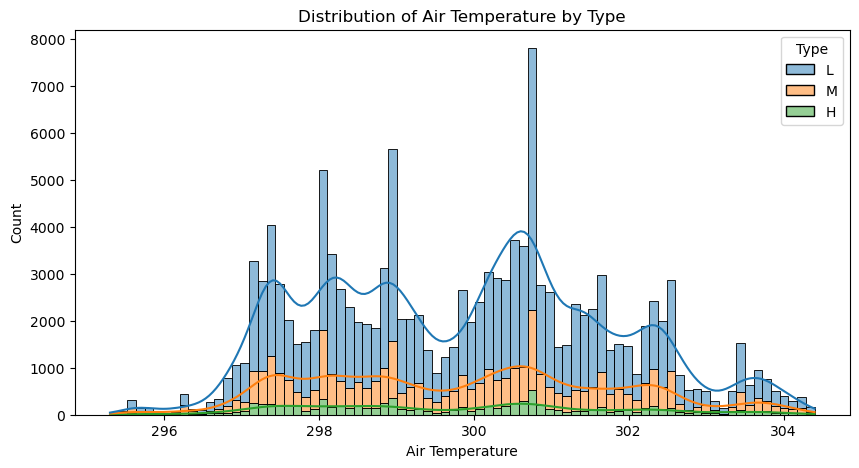

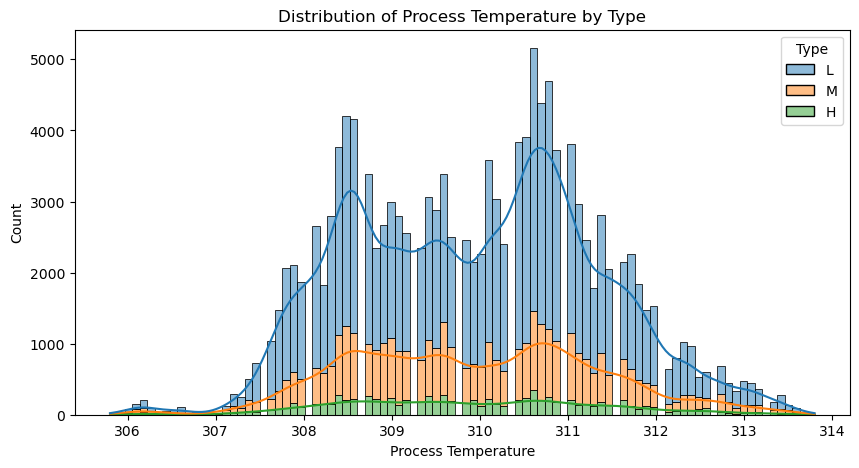

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Plot histogram for Air Temperature by Type
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Air temperature [K]', hue='Type', multiple='stack', kde=True)
plt.title('Distribution of Air Temperature by Type')
plt.xlabel('Air Temperature')
plt.ylabel('Count')
plt.show()

# Plot histogram for Process Temperature by Type
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Process temperature [K]', hue='Type', multiple='stack', kde=True)
plt.title('Distribution of Process Temperature by Type')
plt.xlabel('Process Temperature')
plt.ylabel('Count')
plt.show()


In [144]:
print("\nSummary statistics Befour outlier handling:\n")
print(df.describe())


Summary statistics Befour outlier handling:

                  id  Air temperature [K]  Process temperature [K]  \
count  136429.000000        136429.000000            136429.000000   
mean    68214.000000           299.862776               309.941070   
std     39383.804275             1.862247                 1.385173   
min         0.000000           295.300000               305.800000   
25%     34107.000000           298.300000               308.700000   
50%     68214.000000           300.000000               310.000000   
75%    102321.000000           301.200000               310.900000   
max    136428.000000           304.400000               313.800000   

       Rotational speed [rpm]    Torque [Nm]  Tool wear [min]  \
count           136429.000000  136429.000000    136429.000000   
mean              1520.331110      40.348643       104.408901   
std                138.736632       8.502229        63.965040   
min               1181.000000       3.800000         0.000000  

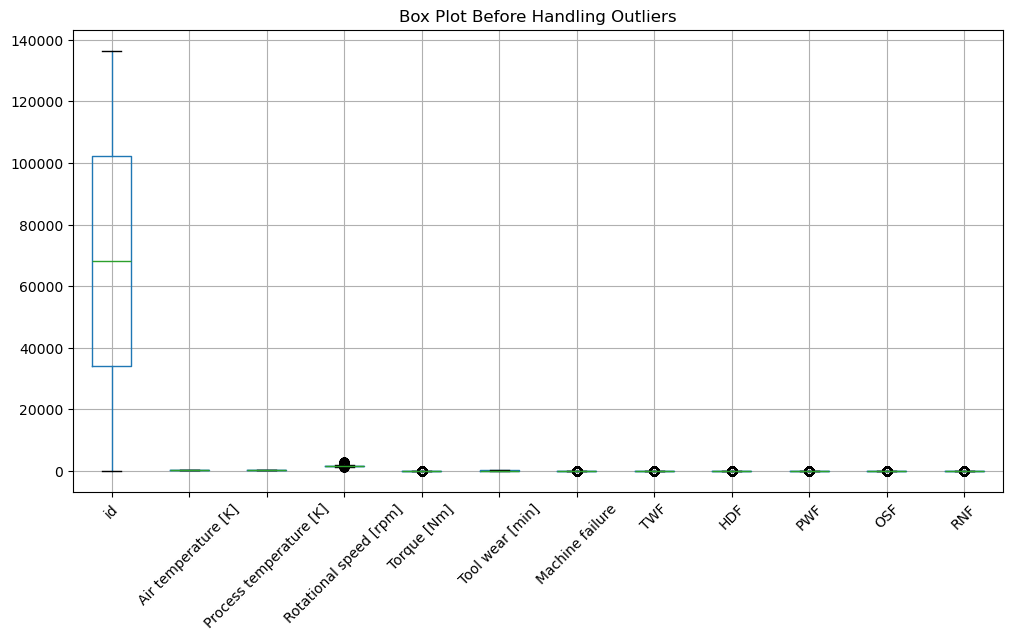

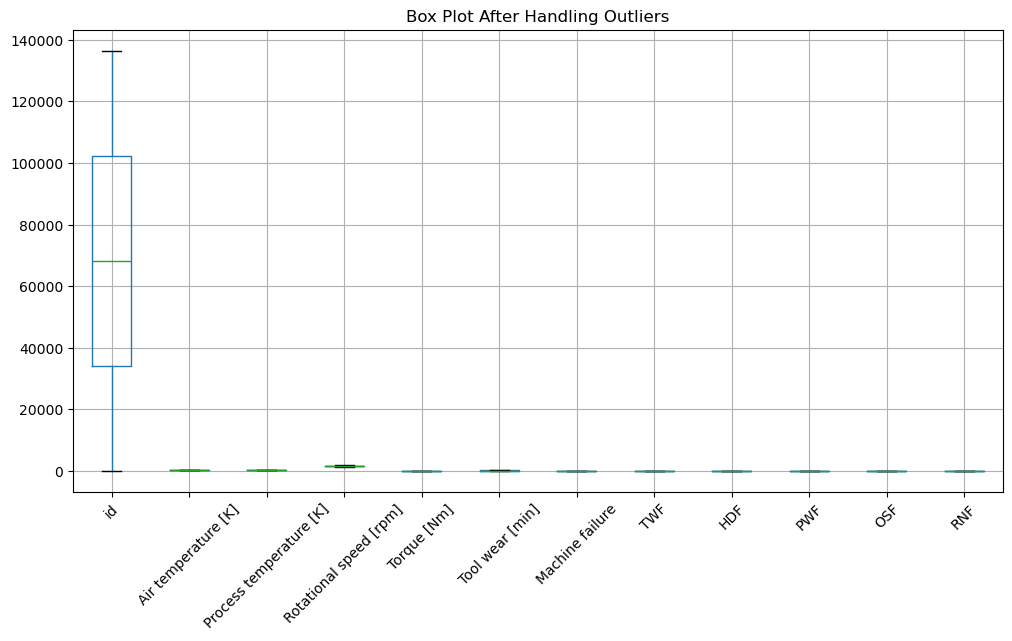

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# outliers with boxplots before handling
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Box Plot Before Handling Outliers")
plt.xticks(rotation=45)
plt.show()


# to handle outliers using IQR
def handle_outliers_iqr(df, column, method='cap'):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if method == 'remove': # remove row withoutliers
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    elif method == 'cap':  # it will remove outliers which are out of range 
        df[column] = df[column].clip(lower_bound, upper_bound)
    return df

# numeric column
# Choose 'cap' to keep data but limit extreme values
for col in numeric_cols:
    df = handle_outliers_iqr(df, col, method='cap')

# boxplots after handling
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Box Plot After Handling Outliers")
plt.xticks(rotation=45)
plt.show()


In [146]:
print("\nSummary statistics after outlier handling:\n")
print(df.describe())


Summary statistics after outlier handling:

                  id  Air temperature [K]  Process temperature [K]  \
count  136429.000000        136429.000000            136429.000000   
mean    68214.000000           299.862776               309.941070   
std     39383.804275             1.862247                 1.385173   
min         0.000000           295.300000               305.800000   
25%     34107.000000           298.300000               308.700000   
50%     68214.000000           300.000000               310.000000   
75%    102321.000000           301.200000               310.900000   
max    136428.000000           304.400000               313.800000   

       Rotational speed [rpm]    Torque [Nm]  Tool wear [min]  \
count           136429.000000  136429.000000    136429.000000   
mean              1514.635224      40.348494       104.408901   
std                118.105451       8.428890        63.965040   
min               1210.000000      17.350000         0.000000   

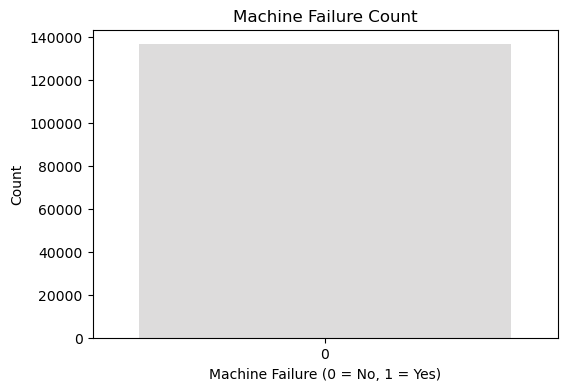

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

failure_counts = df['Machine failure'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette="coolwarm")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Machine Failure Count")
#plt.xticks([0, 1], ['No Failure (0)', 'Failure (1)'])
plt.show()


In [148]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns


# # Compute average temperature per Machine Failure category
# avg_temp = df.groupby('Machine failure')[['Air temperature [K]', 'Process temperature [K]']].mean().reset_index()

# # Melt for easier plotting
# avg_temp_melted = avg_temp.melt(id_vars='Machine failure', 
#                                 value_vars=['Air temperature [K]', 'Process temperature [K]'],
#                                 var_name='Temperature Type', 
#                                 value_name='Average Temperature (K)')

# # Plot
# plt.figure(figsize=(8, 5))
# sns.barplot(data=avg_temp_melted, x='Machine failure', y='Average Temperature (K)', hue='Temperature Type', palette='coolwarm')

# plt.title('Average Air & Process Temperature by Machine Failure')
# plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
# plt.ylabel('Average Temperature (K)')
# plt.legend(title='Temperature Type')
# plt.show()


In [149]:
# import pandas as pd
# import matplotlib.pyplot as plt




# # Clean column names (remove hidden spaces)
# df.columns = df.columns.str.strip()

# # --- Count Failures by Type ---
# twf_counts = df[df['TWF'] == 1]['Type'].value_counts()
# hdf_counts = df[df['HDF'] == 1]['Type'].value_counts()

# # --- Print the counts to confirm data ---
# print("TWF counts:\n", twf_counts)
# print("\nHDF counts:\n", hdf_counts)

# # Handle empty data
# if twf_counts.empty and hdf_counts.empty:
#     print("\n⚠️ No TWF or HDF failures found in your data.")
# else:
#     # Create subplots
#     fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#     # Pie chart for TWF
#     if not twf_counts.empty:
#         axes[0].pie(
#             twf_counts,
#             labels=twf_counts.index,
#             autopct='%1.1f%%',
#             startangle=90,
#             colors=['#66b3ff', '#99ff99', '#ffcc99']
#         )
#         axes[0].set_title('Tool Wear Failure (TWF) by Machine Type')
#     else:
#         axes[0].text(0.5, 0.5, 'No TWF failures', ha='center', va='center', fontsize=12)
#         axes[0].set_title('Tool Wear Failure (TWF) by Machine Type')

#     # Pie chart for HDF
#     if not hdf_counts.empty:
#         axes[1].pie(
#             hdf_counts,
#             labels=hdf_counts.index,
#             autopct='%1.1f%%',
#             startangle=90,
#             colors=['#ff9999', '#66b3ff', '#99ff99']
#         )
#         axes[1].set_title('Heat Dissipation Failure (HDF) by Machine Type')
#     else:
#         axes[1].text(0.5, 0.5, 'No HDF failures', ha='center', va='center', fontsize=12)
#         axes[1].set_title('Heat Dissipation Failure (HDF) by Machine Type')

#     plt.tight_layout()
#     plt.show()


In [150]:
# X_pre.to_csv('Cleaned Dataset2.csv',index=False)


## Splitting of data into training and testing


In [151]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,y,train_size=0.75,random_state=21)
print(f'xtrain.shape: {xtrain.shape}')
print(f'xtest.shape: {xtest.shape}')
print(f'ytrain.shape: {ytrain.shape}')
print(f'ytest.shape: {ytest.shape}')

xtrain.shape: (102321, 13)
xtest.shape: (34108, 13)
ytrain.shape: (102321, 1)
ytest.shape: (34108, 1)


In [152]:

xtrain.head()

,Type_H,Type_L,Type_M,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),TWF,HDF,PWF,OSF,RNF
78401,0.0,1.0,0.0,1.362458,0.259123,-0.888962,1.840860,-0.037660,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
24491,0.0,0.0,1.0,0.664374,0.547897,-0.593437,0.688217,-0.397233,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
26524,0.0,1.0,0.0,0.395880,0.186930,-1.458388,0.100134,-1.507218,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
26420,0.0,0.0,1.0,-0.946589,-0.751584,-2.006191,2.099617,1.072326,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
35654,0.0,1.0,0.0,0.073688,-0.318424,1.417575,-1.417121,-1.085111,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [153]:
ytrain.head()

,Machine failure
78401,0
24491,0
26524,0
26420,0
35654,0


In [170]:
ytrain.value_counts()

Machine failure
0                  100713
1                    1608
Name: count, dtype: int64

In [154]:
ytest.head()

,Machine failure
22333,0
35216,0
112970,0
14905,0
25676,0


## 5. Model Building
Build and compare the following models:
•	Logistic Regression
•	Decision Tree Classifier
•	Random Forest Classifier
•	Naïve Bayee’s Classifier


In [155]:


# Model buidling=> Decision Tree, Logistic Regression, Random Forest, Gradient Boost, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE  


# Evaluation metrics
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report

In [156]:
models = [
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GaussianNB(),
    XGBClassifier()
]

In [157]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc

def evaluate_model_performance(model, xtrain, ytrain, xtest, ytest):
    # Apply SMOTE oversampling to handle class imbalance
    sm = SMOTE(random_state=42)
    xtrain_res, ytrain_res = sm.fit_resample(xtrain, ytrain)

    # Fit the model on resampled training data
    model.fit(xtrain_res, ytrain_res)

    # Predict the outputs
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)

    # Evaluate using F1 score
    f1_train = f1_score(ytrain, ypred_train, average='macro')
    f1_test = f1_score(ytest, ypred_test, average='macro')

    # Evaluate through cross-validation
    scores = cross_val_score(model, xtrain_res, ytrain_res, cv=4, scoring='f1_macro')
    f1_cv = scores.mean()

    # Return all results
    results = {
        'Name': type(model).__name__,
        'F1-score (Train)': f1_train,
        'F1-score (Test)': f1_test,
        'F1-score (CV)': f1_cv
    }
    return results


In [162]:
def evaluate_model(models,xtrain,ytrain,xtest,ytest):
    res = []
    for m in models:
        r = evaluate_model_performance(m,xtrain,ytrain,xtest,ytest)
        res.append(r)
    results_df = pd.DataFrame(res)
    return results_df


def get_auc_score(model, xtrain, ytrain, xtest, ytest):
    sm = SMOTE(random_state=42)
    xtrain_res, ytrain_res = sm.fit_resample(xtrain, ytrain)
    model.fit(xtrain_res, ytrain_res)

    # probability for positive class
    y_prob = model.predict_proba(xtest)[:, 1]

    fpr, tpr, _ = roc_curve(ytest, y_prob)
    aucscore = auc(fpr, tpr)

    return aucscore, fpr, tpr

In [159]:
score_results_df = evaluate_model(models,xtrain,ytrain,xtest,ytest)
score_results_df


,Name,F1-score (Train),F1-score (Test),F1-score (CV)
0,LogisticRegression,0.760501,0.757467,0.893390
1,DecisionTreeClassifier,0.997941,0.755383,0.980603
2,RandomForestClassifier,0.997950,0.885637,0.992131
3,GaussianNB,0.931278,0.924975,0.884075
4,XGBClassifier,0.897825,0.841473,0.982056


In [160]:
score_results_df.sort_values(by = "F1-score (CV)",ascending=False)

,Name,F1-score (Train),F1-score (Test),F1-score (CV)
2,RandomForestClassifier,0.997950,0.885637,0.992131
4,XGBClassifier,0.897825,0.841473,0.982056
1,DecisionTreeClassifier,0.997941,0.755383,0.980603
0,LogisticRegression,0.760501,0.757467,0.893390
3,GaussianNB,0.931278,0.924975,0.884075


In [164]:
aucscores = []

for model in models:
    aucscore, _, _ = get_auc_score(model, xtrain, ytrain, xtest, ytest)
    aucscores.append(aucscore)

score_results_df["AUC Score"] = aucscores
score_results_df

,Name,F1-score (Train),F1-score (Test),F1-score (CV),AUC Score
0,LogisticRegression,0.760501,0.757467,0.893390,0.934659
1,DecisionTreeClassifier,0.997941,0.755383,0.980603,0.882875
2,RandomForestClassifier,0.997950,0.885637,0.992131,0.952833
3,GaussianNB,0.931278,0.924975,0.884075,0.933792
4,XGBClassifier,0.897825,0.841473,0.982056,0.950460


In [167]:
score_results_df.sort_values(by = "AUC Score",ascending=False)

,Name,F1-score (Train),F1-score (Test),F1-score (CV),AUC Score
2,RandomForestClassifier,0.997950,0.885637,0.992131,0.952833
4,XGBClassifier,0.897825,0.841473,0.982056,0.950460
0,LogisticRegression,0.760501,0.757467,0.893390,0.934659
3,GaussianNB,0.931278,0.924975,0.884075,0.933792
1,DecisionTreeClassifier,0.997941,0.755383,0.980603,0.882875


In [168]:
models

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 GaussianNB(),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)]

#ROC-AUC curve#

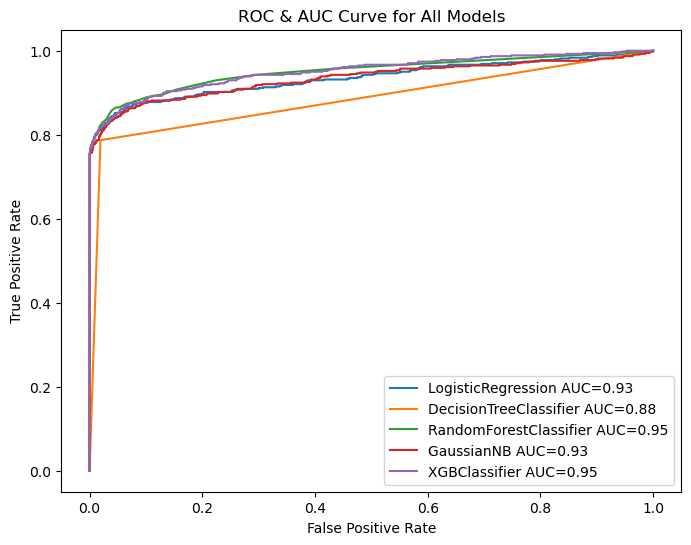

In [169]:
plt.figure(figsize=(8,6))

for model in models:
    name = model.__class__.__name__

    auc_score, fpr, tpr = get_auc_score(model, xtrain, ytrain, xtest, ytest)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc_score:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC & AUC Curve for All Models")
plt.legend()
plt.show()


#NOTE THAT HERE RandomForestClassifier on basis of highest F1-score (cv) AND XGBClassifier on basis of AUC Score

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Create the DataFrame
# data = {
#     "Name": [
#         "LogisticRegression",
#         "RandomForestClassifier",
#         "Navie Bayee's",
#         "XGBClassifier",
#         "DecisionTreeClassifier"
#     ],
#     "f1-score:training": [0.865755, 0.995641, 0.876608, 0.916639, 0.995946],
#     "f1-score:testing": [0.854737, 0.857442, 0.852356, 0.855359, 0.773234],
#     "f1-cv": [0.931269, 0.929670, 0.928557, 0.928394, 0.874119]
# }


In [ ]:
# print(data)

In [ ]:
# ## optinal part 
# df = pd.DataFrame(data)
# x = range(len(df))
# width = 0.25  # width of each bar
# # Plot settings
# x = range(len(df))
# width = 0.25  # width of each bar

# plt.figure(figsize=(10,6))

# plt.bar([i - width for i in x], df["f1-score:training"], width=width, label="Training F1-score")
# plt.bar(x, df["f1-score:testing"], width=width, label="Testing F1-score")
# plt.bar([i + width for i in x], df["f1-cv"], width=width, label="CV F1-score")




# # Labels and title
# plt.xticks(x, df["Name"], rotation=45, ha="right")
# plt.ylabel("F1-score")
# plt.title("Model Comparison: F1-scores (Training, Testing, CV)")
# plt.legend()
# plt.tight_layout()
# plt.show()

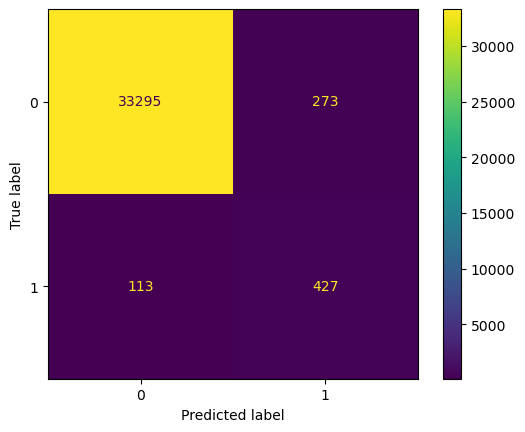

In [ ]:
ConfusionMatrixDisplay.from_estimator(model,xtest,ytest)

In [ ]:
print(classification_report(ytest,model.predict(xtest)))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     33568
           1       0.61      0.79      0.69       540

    accuracy                           0.99     34108
   macro avg       0.80      0.89      0.84     34108
weighted avg       0.99      0.99      0.99     34108



# Finalising RandomForestClassifier

In [ ]:

final_model = RandomForestClassifier()
final_model.fit(xtrain,ytrain)

RandomForestClassifier()

In [ ]:
final_model.score(xtrain,ytrain)

0.9998631756921844

In [ ]:

final_model.score(xtest,ytest)

0.995983347015363

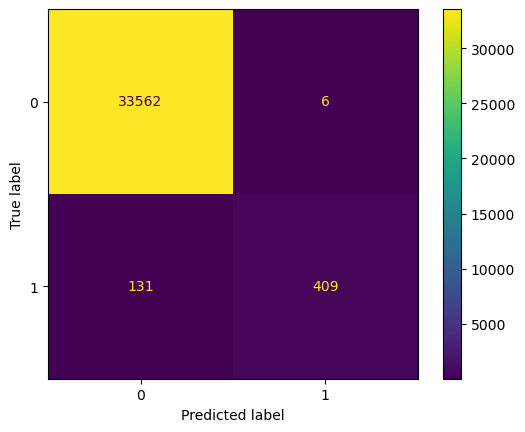

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_model,xtest,ytest)

In [ ]:
print(classification_report(ytest,final_model.predict(xtest)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33568
           1       0.99      0.76      0.86       540

    accuracy                           1.00     34108
   macro avg       0.99      0.88      0.93     34108
weighted avg       1.00      1.00      1.00     34108



## Using this model for final predictions


In [ ]:

path2 = r'datasets-test.csv'
xnew = pd.read_csv(path2)
xnew.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:
xnew_pre = pre.transform(xnew)

In [ ]:
xnew_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,1.308759,1.125444,-0.153753,-0.276240,-0.694271,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,1.0,0.0,0.986567,0.764477,1.388744,-1.358313,-1.366516,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,0.771772,0.331317,0.033653,-0.311525,-0.131461,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,0.0,1.0,0.127386,-0.246230,-0.297912,0.852880,-1.554119,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,1.899446,1.702992,-0.038426,0.111895,0.149943,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [ ]:
print("Training shape:", X_pre.shape)
print("New data shape:", xnew_pre.shape)


Training shape: (136429, 13)
New data shape: (90954, 13)


In [ ]:
xnew_pre = pre.transform(xnew)


In [ ]:
# # Use handle_unknown="ignore" when defining OneHotEncoder
# OneHotEncoder(handle_unknown='ignore')


In [ ]:
print(X_pre.columns)
print(xnew.columns)


Index(['Type_H', 'Type_L', 'Type_M', 'Air temperature (K)',
       'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)',
       'Tool wear (min)', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')
Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [ ]:
xnew_pre = xnew_pre.values  # convert to NumPy array
predicted = final_model.predict(xnew_pre)


In [ ]:
print(X_pre.shape, xnew_pre.shape)
print(type(xnew_pre))
print(xnew_pre[:2])


(136429, 13) (90954, 13)
<class 'numpy.ndarray'>
[[ 0.          1.          0.          1.30875929  1.12544438 -0.15375311
  -0.27623953 -0.69427087 -0.03945048 -0.07202055 -0.04901642 -0.06303833
  -0.04756777]
 [ 0.          1.          0.          0.98656671  0.76447734  1.3887435
  -1.35831267 -1.36651555 -0.03945048 -0.07202055 -0.04901642 -0.06303833
  -0.04756777]]


In [ ]:
predicted = final_model.predict(xnew_pre)
predicted

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [ ]:
xnew['Machine Status Predicted'] = predicted
xnew.to_csv('Predicted_ Results.csv',index=False)

## Visualization of feature importance (only for decision tree-based models)

In a Decision Tree, feature importance is based on how much each feature reduces impurity (Gini).
The features that cause the biggest drop in uncertainty are marked as important.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(xtrain, ytrain)


DecisionTreeClassifier(random_state=42)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model_dt.feature_importances_

array([0.0005893 , 0.00323072, 0.00477645, 0.03288868, 0.03373625,
       0.05150682, 0.06318229, 0.04754874, 0.09310645, 0.31265612,
       0.12614395, 0.23063423, 0.        ])

In [ ]:
importances = pd.Series(model_dt.feature_importances_, index=xtrain.columns)
importances.sort_values(ascending=False)

HDF                        0.312656
OSF                        0.230634
PWF                        0.126144
TWF                        0.093106
Torque (Nm)                0.063182
Rotational speed (rpm)     0.051507
Tool wear (min)            0.047549
Process temperature (K)    0.033736
Air temperature (K)        0.032889
Type_M                     0.004776
Type_L                     0.003231
Type_H                     0.000589
RNF                        0.000000
dtype: float64

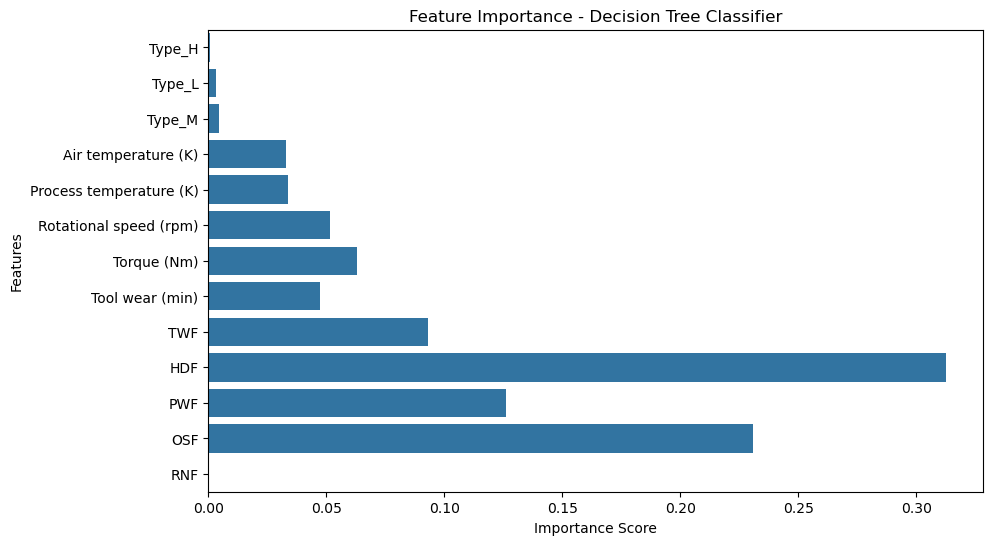

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance - Decision Tree Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Display the feature importances for ensemble-based models 

“I used tree-based models (Random Forest, Gradient Boosting, XGBoost) because they naturally provide feature importance.

A feature is important if splitting on it reduces error a lot.
I compared importance across models to understand which sensor variables consistently affect machine failure.”

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
# Fit ensemble models
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [ ]:
models = [("Random Forest", rf),("XGBoost", xgb)]


In [ ]:
for name, model in models:
    model.fit(xtrain, ytrain)
    importances = pd.Series(model.feature_importances_, index=xtrain.columns).sort_values(ascending=False)

    print(f"\nFeature Importances for {name}:")
    print(importances.round(4))
    # plt.figure(figsize=(10, 6))
    # sns.barplot(x=importances, y=importances.index)
    # plt.title(f"Feature Importance - {name}")
    # plt.xlabel("Importance Score")
    # plt.ylabel("Features")
    # plt.show()


Feature Importances for Random Forest:
HDF                        0.2685
OSF                        0.2068
PWF                        0.1089
Torque (Nm)                0.0982
TWF                        0.0899
Rotational speed (rpm)     0.0766
Tool wear (min)            0.0577
Air temperature (K)        0.0488
Process temperature (K)    0.0389
Type_L                     0.0023
Type_M                     0.0019
Type_H                     0.0013
RNF                        0.0001
dtype: float64

Feature Importances for XGBoost:
HDF                        0.4367
OSF                        0.3098
PWF                        0.1505
TWF                        0.1028
Rotational speed (rpm)     0.0000
Torque (Nm)                0.0000
Air temperature (K)        0.0000
Type_L                     0.0000
Tool wear (min)            0.0000
Type_H                     0.0000
Process temperature (K)    0.0000
Type_M                     0.0000
RNF                        0.0000
dtype: float32


“Feature importance helped me identify which machine sensor readings had the highest impact on predicting failure.
Commonly important features across models were tool wear, process temperature, and air temperature, indicating that mechanical stress and overheating are key failure causes.”